<a href="https://colab.research.google.com/github/Thanuja-v2803/AI-FASHION-SHOPPING-ASSISTANT-CHATBOT/blob/main/mini_project_fashion_fabric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install diffusers transformers accelerate torch


In [22]:
import torch
from diffusers import StableDiffusionPipeline

def generate_local_outfit(gender, category, color, top, bottom, footwear):
    # 1. Load the Model (Standard Stable Diffusion)
    # Note: If you don't have a GPU, remove ".to('cuda')" but it will be very slow.
    model_id = "runwayml/stable-diffusion-v1-5"
    pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)

    # Determine device based on CUDA availability
    if torch.cuda.is_available():
        device = "cuda"
        print("CUDA is available. Using GPU.")
    else:
        device = "cpu"
        print("CUDA is not available. Using CPU. This will be significantly slower.")
        # If using CPU, float16 might not be supported or optimal, so change dtype
        pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float32)

    pipe = pipe.to(device)

    # 2. Construct Prompt
    prompt = (
        f"full body photo of a {gender} wearing {color} {category} fashion, "
        f"wearing {top} and {bottom}, with {footwear}, "
        "highly detailed, 8k, photorealistic, cinematic lighting, fashion photography"
    )

    negative_prompt = "cartoon, illustration, drawing, ugly, deformed, blurry, bad anatomy"

    print("Generating image locally (this may take a moment)...")

    # 3. Generate
    image = pipe(prompt, negative_prompt=negative_prompt).images[0]

    # 4. Save
    filename = "outfit frame.png" # Added .png extension
    image.save(filename)
    print(f"Saved to {filename}")

# --- INPUTS ---
gender = input("Enter gender: ")
category = input("Enter category: ")
color = input("Enter color: ")
product_top = input(f"enter top  :")
product_bottom = input(f"enter bottom :")
footwear = input(f"enter footwear :")
generate_local_outfit(
    gender=gender,
    category=category,
    color=color,
    top=product_top,
    bottom=product_bottom,
    footwear=footwear
)

Enter gender: male
Enter category: casual
Enter color: blue
enter top  :tshirt
enter bottom :shorts
enter footwear :casual slipper


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CUDA is available. Using GPU.
Generating image locally (this may take a moment)...


  0%|          | 0/50 [00:00<?, ?it/s]

Saved to outfit frame.png


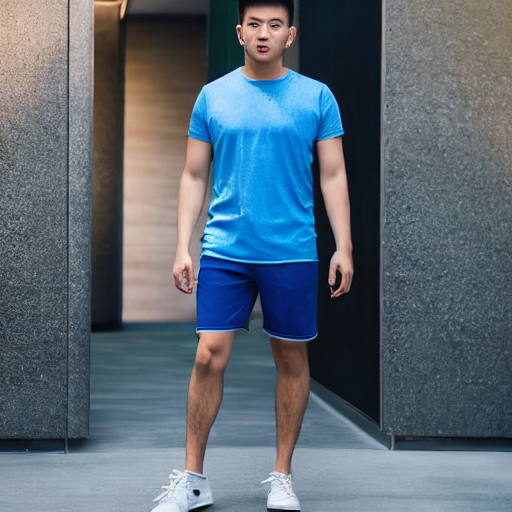

In [23]:
from IPython.display import Image
Image(filename='outfit frame.png')

In [8]:
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModelForImageClassification

# Define device globally
if torch.cuda.is_available():
    device = "cuda"
    print("CUDA is available. Using GPU.")
else:
    device = "cpu"
    print("CUDA is not available. Using CPU. This will be significantly slower.")

# Load image
image = Image.open("outfit frame.png").convert("RGB")

transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

image = transform_test(image).unsqueeze(0).to(device)

# Load pretrained vision transformer model and move to device
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224").to(device)

# Get class names from the model
class_names = model.config.id2label

model.eval()

with torch.no_grad():
    # Preprocess image using the processor
    inputs = processor(images=image, return_tensors="pt").to(device)
    outputs = model(**inputs)

probabilities = F.softmax(outputs.logits, dim=1)

confidence, predicted = torch.max(probabilities,1)

fabric = class_names[predicted.item()]

print("Detected Fabric:", fabric)
print("Confidence:", round(confidence.item()*100,2), "%")

CUDA is available. Using GPU.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.


Detected Fabric: matchstick
Confidence: 3.08 %


In [10]:
top3 = torch.topk(probabilities,3)

print("\nTop-3 Fabric Predictions:")

for i in range(3):

    print(
        class_names[top3.indices[0][i].item()],
        "-",
        round(top3.values[0][i].item()*100,2),
        "%"
    )


Top-3 Fabric Predictions:
matchstick - 3.08 %
nematode, nematode worm, roundworm - 2.88 %
oboe, hautboy, hautbois - 1.32 %


In [11]:
import cv2
import numpy as np

img = cv2.imread("outfit frame.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

texture_score = np.std(gray)

estimated_gsm = int(texture_score * 2)

print("\nEstimated GSM:", estimated_gsm)


Estimated GSM: 128


In [12]:
if estimated_gsm < 150:

    gsm_comfort = "Very Comfortable (Summer Fabric)"

elif estimated_gsm <= 300:

    gsm_comfort = "Moderate Comfort (Regular Wear)"

else:

    gsm_comfort = "Warm Fabric (Winter Wear)"

print("GSM Comfort Level:", gsm_comfort)

GSM Comfort Level: Very Comfortable (Summer Fabric)


In [13]:
temperature = int(input("\nEnter Temperature °C: "))
humidity = int(input("Enter Humidity %: "))


if temperature > 30 and humidity > 60:

    weather_suggestion = "Recommended: Cotton / Linen"

elif temperature < 20:

    weather_suggestion = "Recommended: Wool fabrics"

else:

    weather_suggestion = "Most fabrics comfortable"

print("Weather Recommendation:", weather_suggestion)


Enter Temperature °C: 35
Enter Humidity %: 48
Weather Recommendation: Most fabrics comfortable


In [15]:
comfort_map = {

# Natural fabrics
"cotton":("Very Comfortable","Highly breathable"),
"linen":("Very Comfortable","Excellent summer fabric"),
"silk":("High Comfort","Smooth & lightweight"),
"wool":("Warm Comfort","Good insulation"),
"khadi":("Very Comfortable","Handwoven breathable fabric"),

# Semi-synthetic
"rayon":("Moderate Comfort","Soft but absorbs moisture"),

# Synthetic fabrics
"polyester":("Low Comfort","Less breathable"),
"nylon":("Low Comfort","Traps heat"),

# Heavy fabrics
"denim":("Moderate Comfort","Durable but heavy"),
"corduroy":("Warm Comfort","Winter wear fabric"),

# Light fashion fabrics
"chiffon":("High Comfort","Lightweight & airy"),
"georgette":("High Comfort","Breathable flowing fabric"),

# Traditional fabrics
"batik":("Comfort depends on base fabric","Patterned textile category")

}

# Fix: Define 'fabric' variable, for example, by taking input from the user
fabric = input("Enter a fabric type (e.g., cotton, denim): ")

comfort = comfort_map.get(
fabric.lower(),
("Comfort Unknown","Add dataset label mapping")
)

print("Estimated Fabric Type:", fabric)
print("Comfort Level:", comfort[0])
print("Reason:", comfort[1])
# Fix: Remove 'print(class_names)' as 'class_names' is not defined

Enter a fabric type (e.g., cotton, denim): polyester
Estimated Fabric Type: polyester
Comfort Level: Low Comfort
Reason: Less breathable


In [17]:
natural = ["cotton","linen","silk","khadi","wool"]
synthetic = ["polyester","nylon"]
blended = ["rayon","denim"]
lightweight = ["chiffon","georgette"]

if fabric in natural:
    comfort = ("Very Comfortable","Natural breathable fiber")

elif fabric in synthetic:
    comfort = ("Low Comfort","Synthetic heat-trapping fiber")

elif fabric in blended:
    comfort = ("Moderate Comfort","Blend durability + comfort")

elif fabric in lightweight:
    comfort = ("High Comfort","Light breathable fashion fabric")

else:
    comfort = ("Unknown Comfort","Dataset label not categorized yet")

print("Estimated Fabric Type:", fabric)
print("Comfort Level:", comfort[0])
print("Reason:", comfort[1])

Estimated Fabric Type: polyester
Comfort Level: Low Comfort
Reason: Synthetic heat-trapping fiber
